In [ ]:
python3 -m nuscenes.eval.detection.evaluate \
    --result_path /path/to/your/results.json \
    --eval_set val \
    --dataroot /data/sets/nuscenes \
    --version v1.0-trainval \
    --plot_examples 10 \
    --render_curves 1


In [ ]:
python3 -m nuscenes.eval.detection.evaluate \
    --result_path /OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_N/default/eval/epoch_7862/val/default/final_result/data/results_nusc.json \
    --eval_set val \
    --dataroot /OpenPCDet/datasets/nuscenes \
    --version v1.0-mini \
    --plot_examples 10 \
    --render_curves 1

In [6]:
import os
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot='/OpenPCDet/datasets/nuscenes/v1.0-mini', verbose=True)

# The name of the PCD file you want to look up
target_filename = "n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151616947490.pcd"

# 1. Find the sample_data record
sd_record = None
for sd in nusc.sample_data:
    # Check if the target filename is at the end of the file path
    if sd['filename'].endswith(target_filename):
        sd_record = sd
        break

if sd_record:
    sample_data_token = sd_record['token']   # Use this to render just this sensor data
    sample_token = sd_record['sample_token'] # Use this to lookup your evaluation results.json
    
    print(f"Sample Data Token: {sample_data_token}")
    print(f"Sample Token (for results file): {sample_token}")
else:
    print("File not found in nuScenes metadata. Check your filename or dataset version.")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.3 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
File not found in nuScenes metadata. Check your filename or dataset version.


In [7]:
import json
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box

nusc = NuScenes(version='v1.0-mini', dataroot='/OpenPCDet/datasets/nuscenes/v1.0-mini', verbose=True)

# 1. Load your results file
with open('/OpenPCDet/output/OpenPCDet/tools/cfgs/models/S/D/S_D_N/default/eval/epoch_7862/val/default/final_result/data/results_nusc.json', 'r') as f:
    results_data = json.load(f)

# 2. Pick a specific sample token you want to visualize


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.2 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [8]:
nusc.list_scenes()


scene-0061, Parked truck, construction, intersectio... [18-07-24 03:28:47]   19s, singapore-onenorth, #anns:4622
scene-0103, Many peds right, wait for turning car, ... [18-08-01 19:26:43]   19s, boston-seaport, #anns:2046
scene-0655, Parking lot, parked cars, jaywalker, be... [18-08-27 15:51:32]   20s, boston-seaport, #anns:2332
scene-0553, Wait at intersection, bicycle, large tr... [18-08-28 20:48:16]   20s, boston-seaport, #anns:1950
scene-0757, Arrive at busy intersection, bus, wait ... [18-08-30 19:25:08]   20s, boston-seaport, #anns:592
scene-0796, Scooter, peds on sidewalk, bus, cars, t... [18-10-02 02:52:24]   20s, singapore-queensto, #anns:708
scene-0916, Parking lot, bicycle rack, parked bicyc... [18-10-08 07:37:13]   20s, singapore-queensto, #anns:2387
scene-1077, Night, big street, bus stop, high speed... [18-11-21 11:39:27]   20s, singapore-hollandv, #anns:890
scene-1094, Night, after rain, many peds, PMD, ped ... [18-11-21 11:47:27]   19s, singapore-hollandv, #anns:1762
sc

In [9]:
my_scene = nusc.scene[1]
my_scene



{'token': 'fcbccedd61424f1b85dcbf8f897f9754',
 'log_token': '53cf9c55dd8644bea67b9f009fc1ee38',
 'nbr_samples': 40,
 'first_sample_token': '3e8750f331d7499e9b5123e9eb70f2e2',
 'last_sample_token': '281b92269fd648d4b52d06ac06ca6d65',
 'name': 'scene-0103',
 'description': 'Many peds right, wait for turning car, long bike rack left, cyclist'}

In [12]:
first_sample_token = my_scene['first_sample_token']


In [13]:
my_sample = nusc.get('sample', first_sample_token)
my_sample

{'token': '3e8750f331d7499e9b5123e9eb70f2e2',
 'timestamp': 1533151603547590,
 'prev': '',
 'next': '3950bd41f74548429c0f7700ff3d8269',
 'scene_token': 'fcbccedd61424f1b85dcbf8f897f9754',
 'data': {'RADAR_FRONT': '62fc4b9db2f14104ae681bc8afdd5631',
  'RADAR_FRONT_LEFT': '24ba6892937946f28e64a26febe81686',
  'RADAR_FRONT_RIGHT': '17d44aeb803649ac9a3b09ca288e4768',
  'RADAR_BACK_LEFT': 'd7b1dc5d4048477ea89482f0f3ba04d0',
  'RADAR_BACK_RIGHT': '567307635a67407c9ba269ab2777b8e5',
  'LIDAR_TOP': 'fdddd75ee1d94f14a09991988dab8b3e',
  'CAM_FRONT': '4f5e35aa6c6a426ca945e206fb2f4921',
  'CAM_FRONT_RIGHT': '5ed84fb1dbe24efcb00eb766a22d69d6',
  'CAM_BACK_RIGHT': '8fafdaa824b74553b1a08011d29baf20',
  'CAM_BACK': '1908fe7dc09c474ebc6ea23b4c1c5401',
  'CAM_BACK_LEFT': 'e4233736f4ba4fd5989684f0f1e84377',
  'CAM_FRONT_LEFT': '27f02b3e285d4ca18015535511520b3e'},
 'anns': ['c0571ecf3f9a461db18a70f9a6883e4f',
  '7381b60a2a9147518294969bf78412ec',
  'e912747998bb4485b44841c773d6ae7a',
  '404c7efea9604c3da

In [14]:
nusc.list_sample(my_sample['token'])

Sample: 3e8750f331d7499e9b5123e9eb70f2e2

sample_data_token: 62fc4b9db2f14104ae681bc8afdd5631, mod: radar, channel: RADAR_FRONT
sample_data_token: 24ba6892937946f28e64a26febe81686, mod: radar, channel: RADAR_FRONT_LEFT
sample_data_token: 17d44aeb803649ac9a3b09ca288e4768, mod: radar, channel: RADAR_FRONT_RIGHT
sample_data_token: d7b1dc5d4048477ea89482f0f3ba04d0, mod: radar, channel: RADAR_BACK_LEFT
sample_data_token: 567307635a67407c9ba269ab2777b8e5, mod: radar, channel: RADAR_BACK_RIGHT
sample_data_token: fdddd75ee1d94f14a09991988dab8b3e, mod: lidar, channel: LIDAR_TOP
sample_data_token: 4f5e35aa6c6a426ca945e206fb2f4921, mod: camera, channel: CAM_FRONT
sample_data_token: 5ed84fb1dbe24efcb00eb766a22d69d6, mod: camera, channel: CAM_FRONT_RIGHT
sample_data_token: 8fafdaa824b74553b1a08011d29baf20, mod: camera, channel: CAM_BACK_RIGHT
sample_data_token: 1908fe7dc09c474ebc6ea23b4c1c5401, mod: camera, channel: CAM_BACK
sample_data_token: e4233736f4ba4fd5989684f0f1e84377, mod: camera, channel:

In [15]:
my_sample['data']

{'RADAR_FRONT': '62fc4b9db2f14104ae681bc8afdd5631',
 'RADAR_FRONT_LEFT': '24ba6892937946f28e64a26febe81686',
 'RADAR_FRONT_RIGHT': '17d44aeb803649ac9a3b09ca288e4768',
 'RADAR_BACK_LEFT': 'd7b1dc5d4048477ea89482f0f3ba04d0',
 'RADAR_BACK_RIGHT': '567307635a67407c9ba269ab2777b8e5',
 'LIDAR_TOP': 'fdddd75ee1d94f14a09991988dab8b3e',
 'CAM_FRONT': '4f5e35aa6c6a426ca945e206fb2f4921',
 'CAM_FRONT_RIGHT': '5ed84fb1dbe24efcb00eb766a22d69d6',
 'CAM_BACK_RIGHT': '8fafdaa824b74553b1a08011d29baf20',
 'CAM_BACK': '1908fe7dc09c474ebc6ea23b4c1c5401',
 'CAM_BACK_LEFT': 'e4233736f4ba4fd5989684f0f1e84377',
 'CAM_FRONT_LEFT': '27f02b3e285d4ca18015535511520b3e'}

In [17]:
sensor = 'LIDAR_TOP'
lidar_top_data = nusc.get('sample_data', my_sample['data'][sensor])
lidar_top_data

{'token': 'fdddd75ee1d94f14a09991988dab8b3e',
 'sample_token': '3e8750f331d7499e9b5123e9eb70f2e2',
 'ego_pose_token': 'fdddd75ee1d94f14a09991988dab8b3e',
 'calibrated_sensor_token': 'd051cafdd9fe4d999b413462364d44a0',
 'timestamp': 1533151603547590,
 'fileformat': 'pcd',
 'is_key_frame': True,
 'height': 0,
 'width': 0,
 'filename': 'samples/LIDAR_TOP/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151603547590.pcd.bin',
 'prev': '',
 'next': '53c30444ce0d4217b0d465c0a16ffbb9',
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

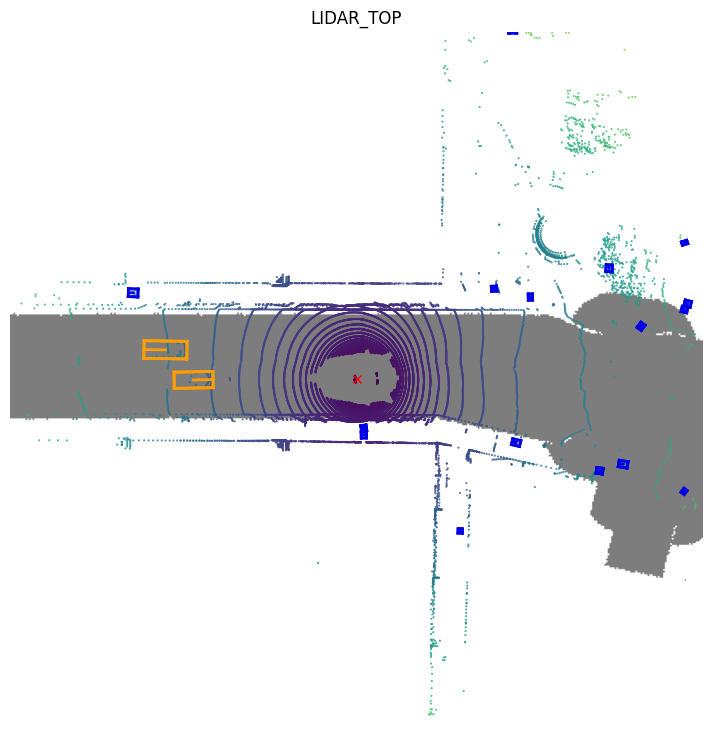

In [18]:
nusc.render_sample_data(lidar_top_data['token'])

KeyError: 'fdddd75ee1d94f14a09991988dab8b3e'